# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('plans.csv')
users = pd.read_csv('users_latam.csv') #completa el código
usage = pd.read_csv('usage.csv') #completa el código

In [5]:
plans.head(5) # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [7]:
users.head() # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [20]:
usage.head( ) # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [9]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [10]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [11]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [12]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [14]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos)
print(users.isna().mean().sort_values(ascending=False)*100) # Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
churn_date    88.350
city          11.725
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
reg_date       0.000
plan           0.000
dtype: float64


In [15]:
 # cantidad de nulos para usage
print(usage.isna().sum()) # Cantidad de valores nulos
print(usage.isna().mean().sort_values(ascending=False)*100) # Proporción de valores nulos

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
duration    55.190
length      44.740
date         0.125
id           0.000
user_id      0.000
type         0.000
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  En users: Falta el 88.3% de los datos de fecha de abandono y el 11.7% de datos de ciudad
  En usage: Faltan el 55.1% de los datos de duración, el 44.7% de longitud y 0.1% de datos faltantes en fecha
- Indica qué harías: ¿imputar, eliminar, ignorar?
      -Datos de fecha de abandono: se IGNORAN y se reportan al area correspondiente para que verifiquen esa fuga        de información.
      -Ciudad: se dejarian como NO DEFINIDO
      -Duración: se IMPUTA
      -Longitud: se IMPUTA

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [24]:
users[['user_id','age']].describe() # explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... es una columna de identificacion, no numerica como tal, sin eMbargo, no muestra valores atipicos
- La columna `age` ... minimo de edad es -999, mediana y media tiene una diferencia lo que nos dice que hay valores atipicos

In [26]:
usage[['user_id','id']].describe() # explorar columnas numéricas de usage

,user_id,id
count,40000.000000,40000.00000
mean,12002.405975,20000.50000
std,1157.279564,11547.14972
min,10000.000000,1.00000
25%,10996.000000,10000.75000
50%,12013.000000,20000.50000
75%,13005.000000,30000.25000
max,13999.000000,40000.00000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ... user_id en ambas tablas muestran diferencias, por lo que se deberia revisar si existen duplicados
- en ID no se observan valores anormales

In [30]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()
users['city'].value_counts()
users['plan'].value_counts()

Basico     2595
Premium    1405
Name: plan, dtype: int64

- La columna `city` ... hay valores faltantes, al usar value_counts() muestra que hay una categoria no valida
- La columna `plan` ... no hay nada atipico en la columna

In [31]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` ... no se observa nada atipico


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  En la columna de age, city
- ¿Qué acción tomarías?  imputar las celdas faltantes

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [3]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [4]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [38]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... existe una fecha imposible que es 2026 siendo que los datos estan hasta el año 2024

In [39]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, ... no hay datos atipicos o imposibles  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) si
- ¿Qué harías con ellas? marcar como nulas en 2026 el cual es una fecha imposible

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [5]:
# Reemplazar -999 por la mediana de age
users['age'] = users['age'].replace(-999, pd.NA)
age_mediana = users['age'].median() 
users['age'] = users['age'].fillna(age_mediana) 

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [10]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)
 
# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [6]:

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()


count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [9]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration_vacia']=usage['duration'].isna().astype(int)
usage.head()
usage.groupby('duration_vacia')['type'].describe()

,count,unique,top,freq
duration_vacia,,,,
0,17924,2,call,17908
1,22076,1,text,22076


In [10]:
# Verificación MAR en usage (Missing At Random) para length
usage['length_vacia']=usage['length'].isna().astype(int)
usage.head()
usage.groupby('length_vacia')['type'].describe()

,count,unique,top,freq
length_vacia,,,,
0,22104,2,text,22092
1,17896,1,call,17896


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`:
Ambas columnas dependen de type: 
-Duración tiene todas las celdas de texto vacias, debido a que un mensaje de texto no tiene duracion como en una llamada
-Length tiene todas las celdas de llamada vacias, debido a que a una llamada no le aplica longitud como en un textos

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [7]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id')[['is_text','is_call','duration']].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [8]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text': 'cant_mensajes','is_call': 'cant_llamadas','duration':'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [11]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(usage_agg, users, on=['user_id'], how='inner')
user_profile.head(5)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [12]:
# Resumen estadístico de las columnas numéricas
user_profile[user_profile['reg_date'].dt.year==2024][['cant_mensajes','cant_llamadas','cant_minutos_llamada','age']].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,1330.000000,1330.000000,1330.000000,1330.000000
mean,5.500000,4.557143,24.126669,48.425564
std,2.382293,2.140329,19.458620,17.962865
min,0.000000,0.000000,0.000000,18.000000
25%,4.000000,3.000000,11.332500,33.000000
50%,5.000000,4.000000,20.325000,48.000000
75%,7.000000,6.000000,32.542500,64.000000
max,16.000000,13.000000,155.690000,79.000000


In [13]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)*100

Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

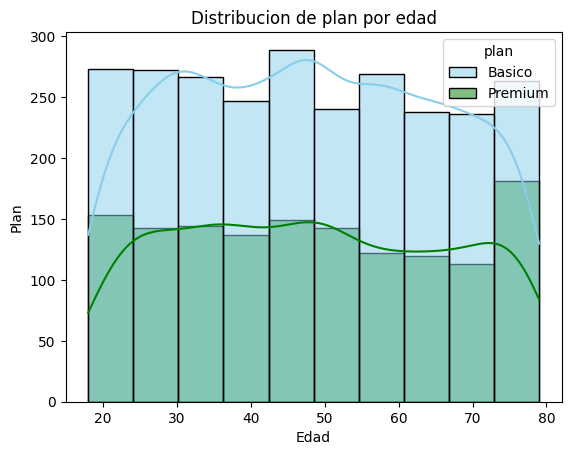

In [33]:
# Histograma para visualizar la edad (age)
sns.histplot(user_profile, x='age', hue='plan', bins=10, palette=['skyblue','green'],kde=True)
plt.title('Distribucion de plan por edad')
plt.xlabel('Edad')
plt.ylabel('Plan')
plt.show()

💡Insights: 
- En la adquisicion de planes por edad, se observa que las personas mayores a 75 años con quienes adquieren mas planes premium, sin embargo la diferencia es muy poca, las demas edades de comportan de una manera similar.

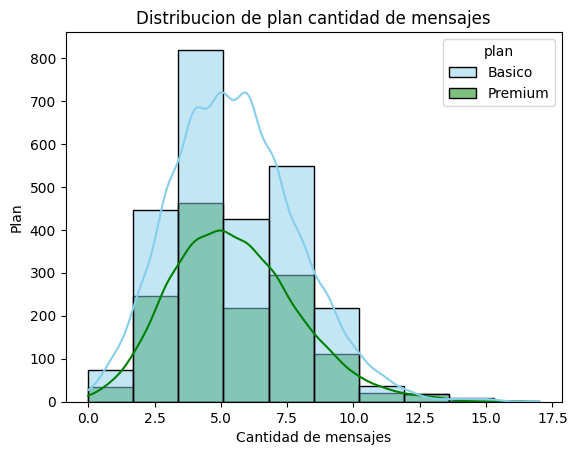

In [32]:
# Histograma para visualizar la cant_mensajes
sns.histplot(user_profile, x='cant_mensajes', hue='plan', bins=10, palette=['skyblue','green'], kde=True)
plt.title('Distribucion de plan cantidad de mensajes')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Plan')
plt.show()

💡Insights: 
- Se observa que los usuarios con un plan premium, envian una mayor cantidad de mensajes, en comparacion con los usuarios de plan basico

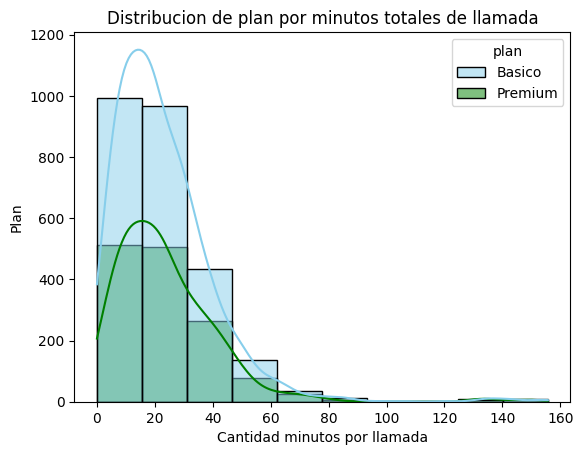

In [35]:
# Histograma para visualizar la cant_llamadas

sns.histplot(user_profile, x='cant_minutos_llamada', hue='plan', bins=10, palette=['skyblue','green'], kde=True)
plt.title('Distribucion de plan por minutos totales de llamada')
plt.xlabel('Cantidad minutos por llamada')
plt.ylabel('Plan')
plt.show()


💡Insights: 
- Distribución los usuarios premium muestran un patron ligeramente mayor en la cantidad de llamadas realizadas en comparacion de los usuarios con plan basico

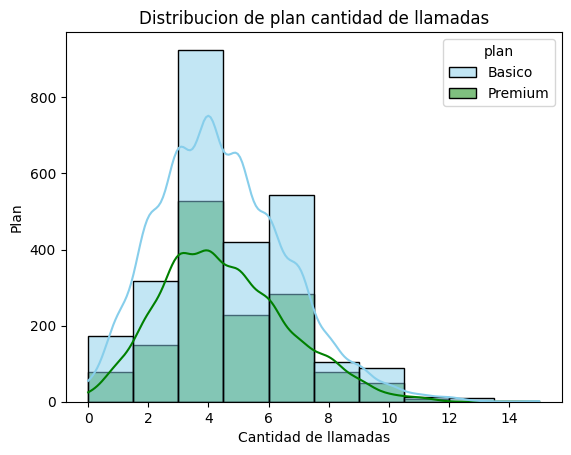

In [36]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(user_profile, x='cant_llamadas', hue='plan', bins=10, palette=['skyblue','green'], kde=True)
plt.title('Distribucion de plan cantidad de llamadas')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Plan')
plt.show()


💡Insights: 
- La distribucion se muestra bastante simular entre planes, sin embargo, se sigue observando una ligera mayoria en el plan premium

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

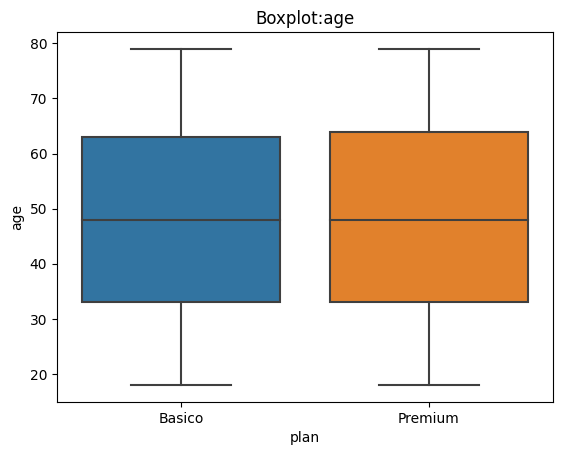

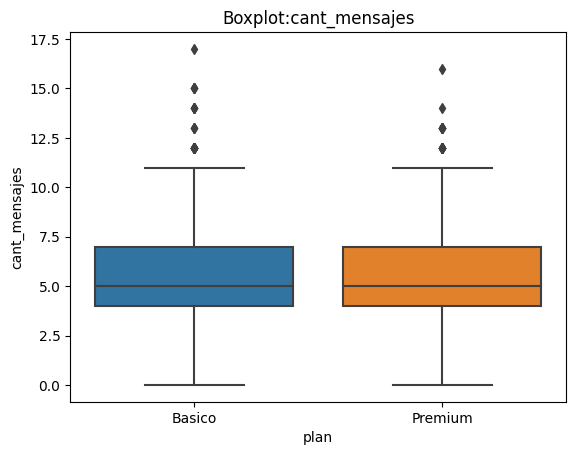

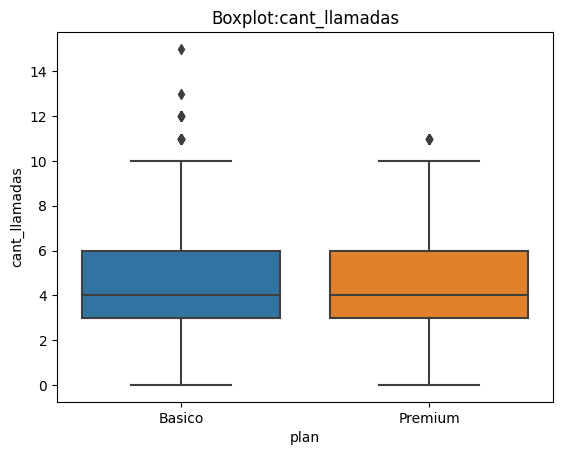

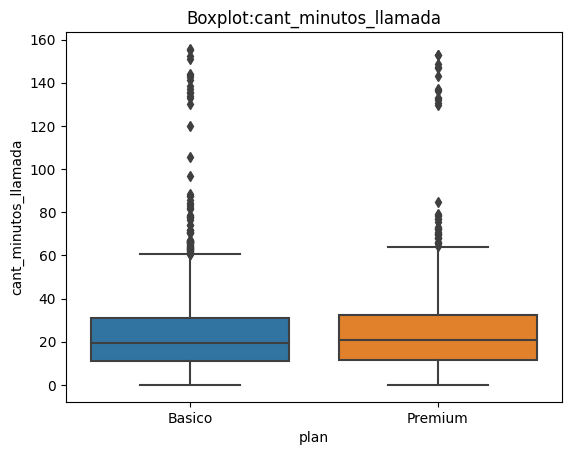

In [51]:

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data= user_profile, x='plan', y=col)
    plt.title(f'Boxplot:{col}')
    plt.show()


💡Insights: 
- Age: ...(presenta o no outliers No presenta outliers
- cant_mensajes: ...Si presenta outliers
- cant_llamadas: ...Si presenta outliers
- cant_minutos_llamada: ...Si presenta outliers

In [14]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1= user_profile[col].quantile(0.25)
    Q3= user_profile[col].quantile(0.75)
    IQR= Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    print(f"{col}")
    print(f"Lower: {lower}")
    print(f"Upper: {upper}\n")


cant_mensajes
Lower: -0.5
Upper: 11.5

cant_llamadas
Lower: -1.5
Upper: 10.5

cant_minutos_llamada
Lower: -19.322500000000005
Upper: 61.8575



In [15]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? se debe mantener ya que aunque hay una pequeña diferencia con el maximo, se debe a usuarios con mayor intensidad de uso
- cant_llamadas: mantener o no outliers, porqué? se debe mantener ya que aunque hay una pequeña diferencia con el maximo, se debe a usuarios con mayor intensidad de uso
- cant_minutos_llamada: mantener o no outliers, porqué? se debe mantener ya que no hay outliers, todo esta dentro del rango esperado

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [31]:
# Crear columna grupo_uso
def grupo_uso(row):
    llamadas=row['cant_llamadas']
    mensajes=row['cant_mensajes']
    if pd.isna(llamadas) or pd.isna(mensajes):
        return 'Error en Datos'
    if llamadas <5 and mensajes <5: 
        return 'Bajo uso'
    elif llamadas <=10 and mensajes <=10: 
        return 'Uso medio'
    else: 
        return 'Alto uso'
user_profile['grupo_uso']= user_profile.apply(grupo_uso, axis=1)

In [20]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [33]:
# Crear columna grupo_edad
def grupo_edad(row):
    edad=row['age']
  
    if pd.isna(edad):
        return 'Error en Datos'
    if edad <30: 
        return 'Joven'
    elif edad <=60: 
        return 'Adulto'
    else: 
        return 'Adulto mayor'
user_profile['grupo_edad']= user_profile.apply(grupo_edad, axis=1)

In [25]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

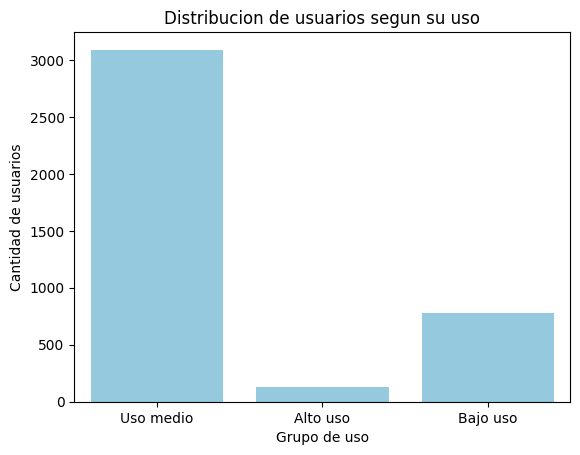

In [32]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso',color='skyblue')
plt.title('Distribucion de usuarios segun su uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

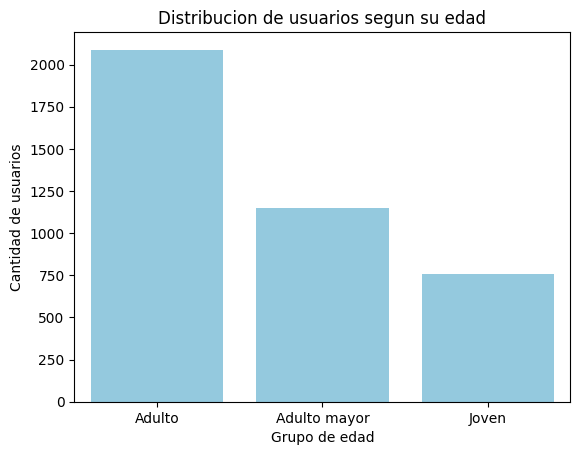

In [34]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad',color='skyblue')
plt.title('Distribucion de usuarios segun su edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenía originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
En users: faltaban el 88.3% de los datos de Fecha de abandono y en la columna Ciudad_ faltaban el 11.7%

En usage: Faltaban el 55.1% de los datos de Duración, en la columna longitud el 44.7% de datos y el 0.1% de datos en la columna fecha

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
   Lo cliente se segmentaron por USO en Bajo uso, Medio uso y Alto uso: se identifico que los usuarios de medio uso son la mayoria basandose en la cantidad de llamadas y mensajes registrados, oscilando entre 5 a 10 llamadas y de 5 a 10 mensajes realizados y los usuarios con un alto uso son la minoria.
    En cuanto a la segmentacion por EDAD, se dividieron en Joven, Adulto y Adulto mayor, siendo el grupo de Adulto con mayor cantidad de usuarios los cuales oscilan en una edad de 30 a 60 años y el grupo que muestra menor cantidad de usuarios son los jovenes.
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
  El segmento de Adultos y de uso medio son los grupos valiosos para la empresa, ya que nos podemos enfocar en atraer a mas personas con ese rango de edad y manejar promociones de acuerdo al uso, con campanas de marketing
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
se encontraon outliers en cantidad de mensajes, cantidad de llamadas y cantidad de minutos por llamadas por planes, aunque con una diferencia menor con respecto al maximo, esto nos indica que esos outliers se deben a usuarios con mayor intensidad de uso, por lo que son datos reales

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
Enfocar campañas de marketing a usuarios que tengan entre 30 y 60 años ya que es el rango de edad que es mas atraido por la empresa ConnectaTel.
Tambien, aplicar promociones o paquetes de acuerdo al uso de llamadas y mensajes, se observa que la mayoria de los usuarios realizan entre 5 a 10 llamadas y de 5 a 10 mensajes.
✍️ **Escribe aquí tu análisis ejecutivo:

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- se observaron valores faltantes en la tabla de users en las columnas de fecha de abandono y ciudad.
- se observaron valores faltantes en la tabla de usage en las columnas de datos de duracion y longitud, sin embargo, se observo que esta ausencia se debia a que en la columna type en texto no aplica duracion y en longitud no aplica longitud.
- en la columna age marcaba valores erroneos (-999), se remplazo por la media
- en city, marcaba un sentinel (?), se remplazo por valores nulos NA
- en rage_date, marcaba una fecha imposible (2026), se remplazo por valores nulos NA

🔍 **Segmentos por Edad**
-  En cuanto a la segmentacion por EDAD, se dividieron en Joven, Adulto y Adulto mayor, siendo el grupo de Adulto con mayor cantidad de usuarios los cuales oscilan en una edad de 30 a 60 años
-  El grupo que muestra menor cantidad de usuarios son los Jovenes.


📊 **Segmentos por Nivel de Uso**
- Lo cliente se segmentaron por USO en Bajo uso, Medio uso y Alto uso: se identifico que los usuarios de medio uso son la mayoria basandose en la cantidad de llamadas y mensajes registrados, oscilando entre 5 a 10 llamadas y de 5 a 10 mensajes realizados
- Los usuarios con un Alto uso son la minoria.
  
➡️ Esto sugiere que .. El segmento de usuarios considerados Adultos que tiene una edad entre 30 y 60 años son los usuarios mas valiosos de la empresa. Tambien aquellos usuarios que tienen un uso medio de su servicio telefonico, la cual oscila entre 5 a 10 llamadas y de 5 a 10 mensajes realizados. Son los usuarios

💡 **Recomendaciones**
-Enfocar campañas de marketing a usuarios que tengan entre 30 y 60 años ya que es el rango de edad que es mas atraido por la empresa ConnectaTel.
Tambien, aplicar promociones o paquetes de acuerdo al uso de llamadas y mensajes, se observa que la mayoria de los usuarios realizan entre 5 a 10 llamadas y de 5 a 10 mensajes. 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`